In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load Dataset
data = pd.read_csv('Amazon Sale Report.csv')

# Data Cleaning
# Drop columns with 100% missing values
data.dropna(axis=1, how='all', inplace=True)

# Fill missing numerical values with median
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[numerical_cols] = data[numerical_cols].apply(lambda col: col.fillna(col.median()))

# Fill missing categorical values with mode
categorical_cols = data.select_dtypes(include=['object', 'bool']).columns
data[categorical_cols] = data[categorical_cols].apply(
    lambda col: col.fillna(col.mode()[0]) if col.isnull().any() else col
)

# Feature Engineering
# Convert 'Date' to datetime format with a specified format
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d', errors='coerce')

# Feature 1: Delivery Delay (Days)
# Map known delivery days for each service level
if 'ship-service-level' in data.columns:
    delivery_days_map = {
        'Standard': 5,    # Example: Standard delivery takes 5 days
        'Expedited': 2    # Example: Expedited delivery takes 2 days
    }
    data['Delivery Delay (Days)'] = data['ship-service-level'].map(delivery_days_map)

# Replace NaNs in Delivery Delay with the median
if 'Delivery Delay (Days)' in data.columns:
    data['Delivery Delay (Days)'].fillna(data['Delivery Delay (Days)'].median(), inplace=True)

# Feature 2: Total Sales Revenue
if 'Qty' in data.columns and 'Amount' in data.columns:
    data['Total Sales Revenue'] = data['Qty'] * data['Amount']

# Data Normalization/Encoding
# Standardize numerical features
numerical_features = ['Qty', 'Amount', 'Total Sales Revenue']
if not data[numerical_features].empty:
    scaler = StandardScaler()
    data[numerical_features] = scaler.fit_transform(data[numerical_features])

# One-Hot Encoding for categorical features
categorical_features = ['Status', 'Fulfilment', 'Sales Channel', 'Category', 'Size', 'Courier Status']
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)

# Cleaned Data Overview
print("\nCleaned Data Overview:")
print(data.info())

# Preview of new features
if 'Delivery Delay (Days)' in data.columns and 'Total Sales Revenue' in data.columns:
    print("\nPreview of New Features:")
    print(data[['Delivery Delay (Days)', 'Total Sales Revenue']].head())
else:
    print("New features are not present in the data.")

C:\Users\aaaji\AppData\Local\Temp\ipykernel_10732\974972060.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Delivery Delay (Days)'].fillna(data['Delivery Delay (Days)'].median(), inplace=True)



Cleaned Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 50 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   index                                 128976 non-null  int64         
 1   Order ID                              128976 non-null  object        
 2   Date                                  0 non-null       datetime64[ns]
 3   ship-service-level                    128976 non-null  object        
 4   Qty                                   128976 non-null  float64       
 5   currency                              128976 non-null  object        
 6   Amount                                128976 non-null  float64       
 7   ship-city                             128976 non-null  object        
 8   ship-state                            128976 non-null  object        
 9   ship-postal-code                   

## Linear Regression (for Sales Prediction).

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming `data` is the cleaned dataset from the context
# Define target variable and features
target = 'Total Sales Revenue'
features = [col for col in data.columns if col != target]

# Split data into features (X) and target (y)
X = data[features]
y = data[target]

# Drop irrelevant columns (e.g., Order ID, Date, etc.)
irrelevant_columns = ['Order ID', 'Date', 'ship-city', 'ship-state', 'ship-country', 'currency', 'fulfilled-by']
X = X.drop(columns=irrelevant_columns, errors='ignore')

# Verify that all remaining columns are numeric
non_numeric_columns = X.select_dtypes(include=['object']).columns
if not non_numeric_columns.empty:
    print(f"Non-numeric columns detected: {non_numeric_columns}")
    # Handle non-numeric columns (if any) using encoding
    X = pd.get_dummies(X, columns=non_numeric_columns, drop_first=True)

# Proceed with model training as before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the evaluation metrics
print("Model Evaluation:")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Non-numeric columns detected: Index(['ship-service-level'], dtype='object')
Model Evaluation:
R-squared: 0.97
Mean Absolute Error (MAE): 0.04
Root Mean Squared Error (RMSE): 0.15


In [3]:
# Convert 'ship-service-level' to one-hot encoding if it's not already encoded
if 'ship-service-level' in X.columns:
    X = pd.get_dummies(X, columns=['ship-service-level'], drop_first=True)

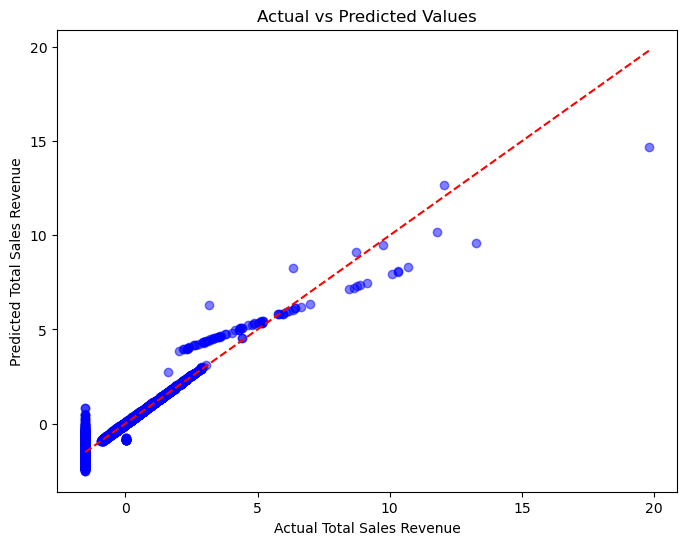

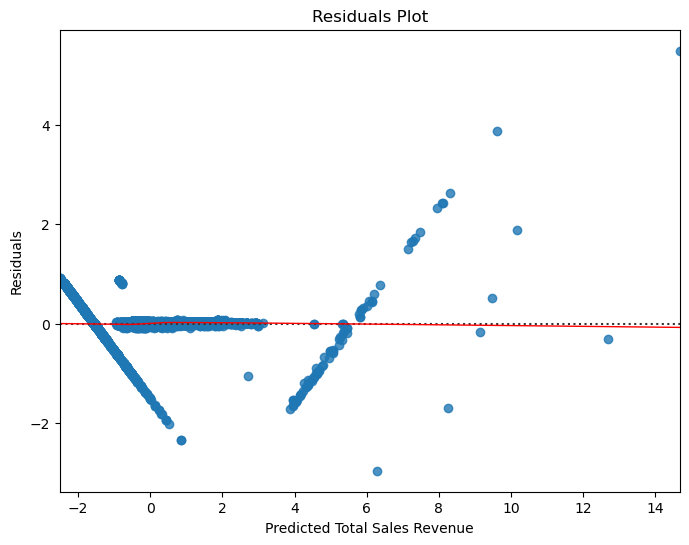

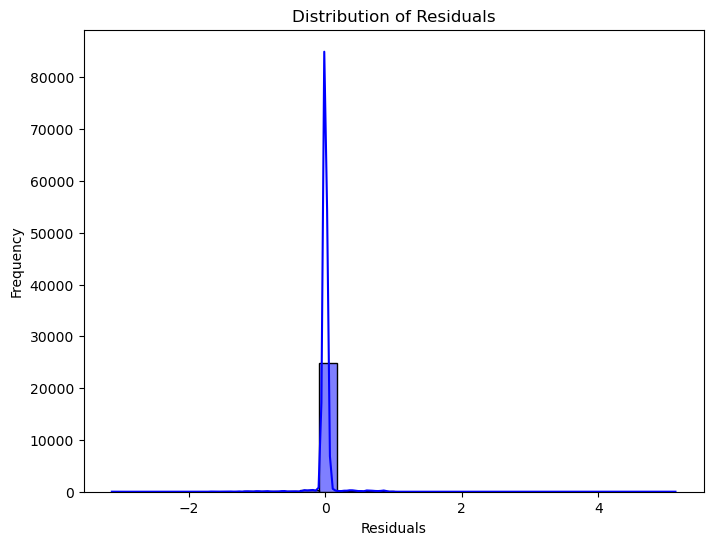

R-squared: 0.97
Mean Absolute Error (MAE): 0.04
Root Mean Squared Error (RMSE): 0.15


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Actual vs Predicted Values (Scatter Plot)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Total Sales Revenue')
plt.ylabel('Predicted Total Sales Revenue')
plt.show()

# 2. Residuals Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.title('Residuals Plot')
plt.xlabel('Predicted Total Sales Revenue')
plt.ylabel('Residuals')
plt.show()

# 3. Histogram of Residuals
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# 4. Model Evaluation Metrics
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

## Explanation:
### Linear Regression Model Evaluation

The **Linear Regression** model was built to predict the **Total Sales Revenue** based on various features in the dataset. Below are the key results from the model evaluation:

#### Key Evaluation Metrics:
- **R-squared**: 0.97 – The model explains 97% of the variance in the target variable (Total Sales Revenue), indicating a strong fit to the data.
- **Mean Absolute Error (MAE)**: 0.04 – On average, the model's predictions are off by about 0.04 units of sales revenue.
- **Root Mean Squared Error (RMSE)**: 0.15 – The RMSE suggests that the model's prediction errors are relatively small, with a typical error magnitude of 0.15 units.

#### Model Visualization:
1. **Actual vs Predicted Values (Scatter Plot)**:
   The scatter plot shows a strong correlation between the actual and predicted sales revenue values, with points clustered around the red diagonal line, which represents perfect predictions. The model is performing well in predicting total sales revenue.

2. **Residuals Plot**:
   The residuals plot indicates that the residuals (differences between actual and predicted values) are randomly scattered around 0, which is a good indication of model fit. There are no obvious patterns, suggesting that the model has captured the relationships in the data effectively.

3. **Histogram of Residuals**:
   The histogram shows that the residuals follow a roughly normal distribution, which is a desirable property for linear regression models. This suggests that the model’s assumptions hold reasonably well.

#### Challenges & Considerations:
- **Non-Numeric Data**: A non-numeric feature, `ship-service-level`, was detected and converted to one-hot encoding during preprocessing. This conversion ensured that categorical data did not impede the model's ability to learn meaningful patterns.
- **Feature Selection**: Although the model performs well, it is important to check for potential multicollinearity or unnecessary features that might be included. Feature selection and regularization could help improve the model’s interpretability and efficiency.

### Conclusion:
The **Linear Regression model** performed well, with high accuracy (R² = 0.97) and low error metrics (MAE = 0.04, RMSE = 0.15). The model is robust for predicting total sales revenue but can be further optimized with techniques like feature selection or regularization if necessary. The visualizations indicate that the model has captured the data's underlying trends, and the residuals analysis suggests no major issues with model assumptions.